<a href="https://colab.research.google.com/github/brimas3/DATA342-Lab-1/blob/main/DATA342_Lab_3_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 1

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install Required Libraries

!pip install openpyxl matplotlib pandas
!pip install openpyxl matplotlib pandas scikit-learn statsmodels

In [ ]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Load Excel File

import requests
import pandas as pd

file_id = '14detpDac5-JgJ4prGiXZ2UEJQM3UmzGUnJLZ-ERWT64'
url = f'https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx'
response = requests.get(url)

if response.status_code == 200:
    with open('DATA342 Lab 1 Data (Netflix vs. Disney).xlsx', 'wb') as f:
        f.write(response.content)
    df = pd.read_excel('DATA342 Lab 1 Data (Netflix vs. Disney).xlsx', sheet_name='Daily Returns 2024', engine='openpyxl')
else:
    print(f"Error downloading file: {response.status_code}")


In [ ]:
# Display Sample Rows

print(df.head())

        Date Ticker  Adj Close  Daily Return
0 2024-01-02   NFLX     468.50           NaN
1 2024-01-03   NFLX     470.26      0.003757
2 2024-01-04   NFLX     474.67      0.009378
3 2024-01-05   NFLX     474.06     -0.001285
4 2024-01-08   NFLX     485.03      0.023141


In [ ]:
# Clean and Format the Data

df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Daily Return'])

In [ ]:
# Separate Data

nflx_df = df[df['Ticker'] == 'NFLX'].copy()
dis_df = df[df['Ticker'] == 'DIS'].copy()

In [ ]:
# Display Sample Rows

print("\nNetflix Daily Returns:")
print(nflx_df[['Date', 'Adj Close', 'Daily Return']].head())

print("\nDIS Daily Returns:")
print(dis_df[['Date', 'Adj Close', 'Daily Return']].head())


Netflix Daily Returns:
        Date  Adj Close  Daily Return
1 2024-01-03     470.26      0.003757
2 2024-01-04     474.67      0.009378
3 2024-01-05     474.06     -0.001285
4 2024-01-08     485.03      0.023141
5 2024-01-09     482.09     -0.006061

DIS Daily Returns:
          Date  Adj Close  Daily Return
251 2024-01-03      90.44     -0.899559
252 2024-01-04      89.37     -0.011831
253 2024-01-05      89.70      0.003693
254 2024-01-08      90.34      0.007135
255 2024-01-09      88.49     -0.020478


/tmp/ipython-input-2952745585.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([nflx_df['Daily Return'], dis_df['Daily Return']], labels=['NFLX', 'DIS'])


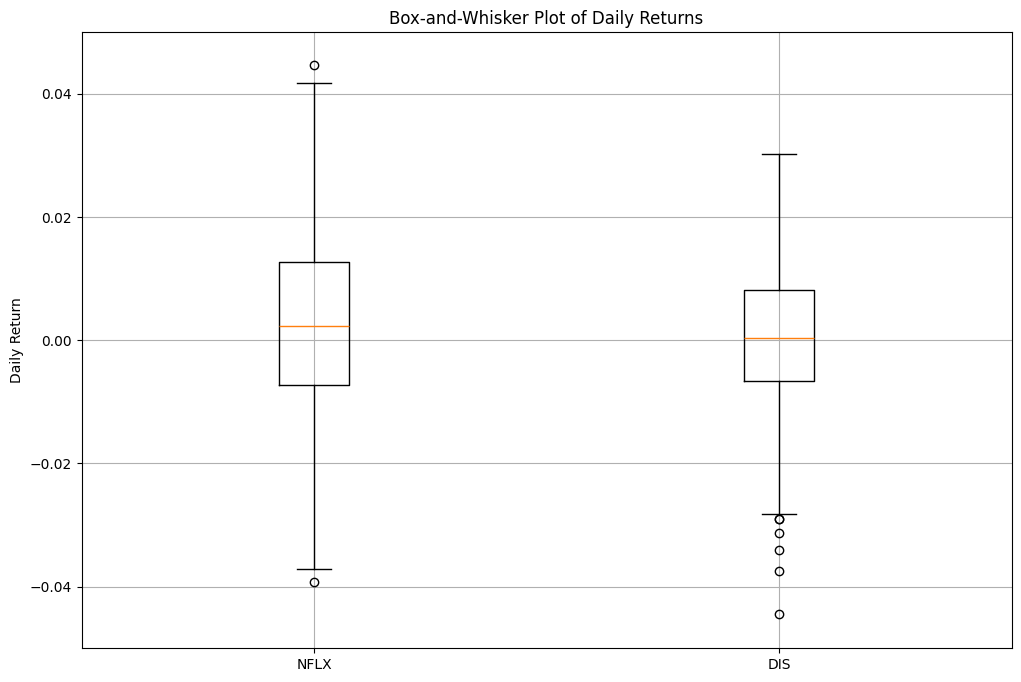

In [ ]:
plt.figure(figsize=(12, 8))
plt.boxplot([nflx_df['Daily Return'], dis_df['Daily Return']], labels=['NFLX', 'DIS'])
plt.title('Box-and-Whisker Plot of Daily Returns')
plt.ylabel('Daily Return')
plt.ylim(-0.05, 0.05)
plt.grid(True)
plt.show()

Lab 2

In [ ]:
from scipy import stats
import numpy as np

# Updated descriptive stats function
def descriptive_stats(series):
    stats_dict = {
        'Mean': series.mean(),
        'Standard Error': series.sem(),  # Added Standard Error
        'Median': series.median(),
        'Mode': series.mode().iloc[0] if not series.mode().empty else '#N/A',  # Handle #N/A for empty mode
        'Standard Deviation': series.std(),
        'Sample Variance': series.var(),
        'Kurtosis': series.kurtosis(),
        'Skewness': series.skew(),
        'Range': series.max() - series.min(),
        'Minimum': series.min(),
        'Maximum': series.max(),
        'Sum': series.sum(),  # Added Sum
        'Count': series.count()  # Added Count
    }
    return stats_dict

# Compute descriptive statistics for both stocks
nflx_stats = descriptive_stats(nflx_df['Daily Return'])
dis_stats = descriptive_stats(dis_df['Daily Return'])

# Print the results for Netflix (same format)
print("Descriptive Statistics for Netflix (NFLX):")
for key, value in nflx_stats.items():
    if isinstance(value, (float, np.float64)):
        print(f"{key}: {value:.9f}")  # Increased precision
    else:
        print(f"{key}: {value}")

# Print the results for Disney (custom format order)
print("\nDescriptive Statistics for Disney (DIS):")
dis_output_order = [
    'Mean',
    'Standard Error',
    'Median',
    'Mode',
    'Standard Deviation',
    'Sample Variance',
    'Kurtosis',
    'Skewness',
    'Range',
    'Minimum',
    'Maximum',
    'Sum',
    'Count'
]

for key in dis_output_order:
    value = dis_stats.get(key)
    if isinstance(value, (float, np.float64)):
        print(f"{key}: {value:.9f}")
    else:
        print(f"{key}: {value}")

Descriptive Statistics for Netflix (NFLX):
Mean: 0.002787152
Standard Error: 0.001176874
Median: 0.002366699
Mode: -0.090932914
Standard Deviation: 0.018608014
Sample Variance: 0.000346258
Kurtosis: 9.616669621
Skewness: 0.903436269
Range: 0.201803270
Minimum: -0.090932914
Maximum: 0.110870356
Sum: 0.696787964
Count: 250

Descriptive Statistics for Disney (DIS):
Mean: -0.002671012
Standard Error: 0.003746899
Median: 0.000395588
Mode: -0.899559100
Standard Deviation: 0.059243669
Sample Variance: 0.003509812
Kurtosis: 213.166863718
Skewness: -14.017761272
Range: 1.014554500
Minimum: -0.899559100
Maximum: 0.114995400
Sum: -0.667752929
Count: 250


In [ ]:
# Hypothesis Testing: Independent t-test
t_stat, p_value = stats.ttest_ind(nflx_df['Daily Return'], dis_df['Daily Return'], equal_var=False)
print("\nHypothesis Testing (Independent t-test):")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


Hypothesis Testing (Independent t-test):
T-statistic: 1.3897736264517115
P-value: 0.16563617277941803


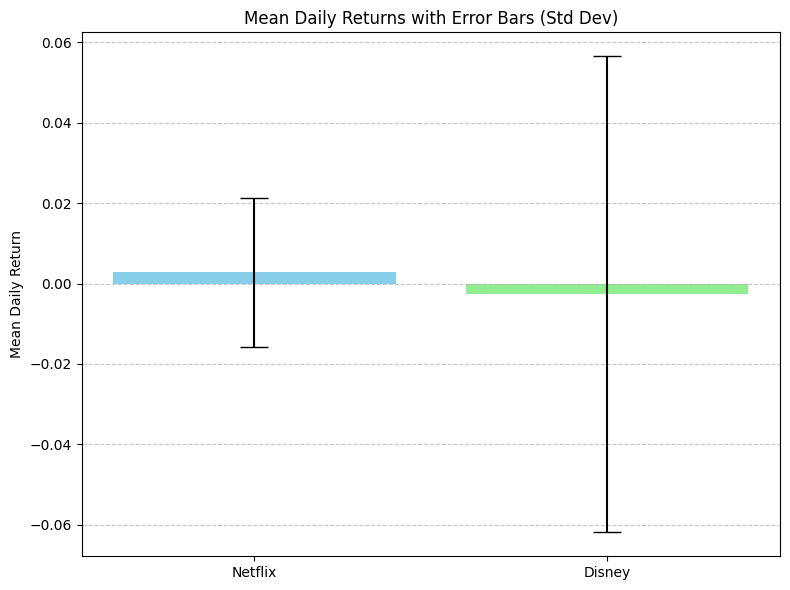

In [ ]:
# Install required libraries (if not already installed)
!pip install pandas matplotlib openpyxl scipy

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the Excel file from Google Drive or URL
file_path = '/content/DATA342 Lab 1 Data (Netflix vs. Disney).xlsx'
df = pd.read_excel('DATA342 Lab 1 Data (Netflix vs. Disney).xlsx', sheet_name='Daily Returns 2024', engine='openpyxl')

# Clean and filter the data
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['Daily Return'])

# Separate Netflix and Disney data
nflx_df = df[df['Ticker'] == 'NFLX'].copy()
dis_df = df[df['Ticker'] == 'DIS'].copy()

# Compute mean and standard deviation for error bars
mean_nflx = nflx_df['Daily Return'].mean()
std_nflx = nflx_df['Daily Return'].std()
mean_dis = dis_df['Daily Return'].mean()
std_dis = dis_df['Daily Return'].std()

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(nflx_df['Daily Return'], dis_df['Daily Return'], equal_var=False)

# Create bar plot with error bars
means = [mean_nflx, mean_dis]
errors = [std_nflx, std_dis]
labels = ['Netflix', 'Disney']
colors = ['skyblue', 'lightgreen']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, means, yerr=errors, capsize=10, color=colors)

# Add asterisk if p-value < 0.05
if p_value < 0.05:
    max_height = max(means)
    y = max_height + max(errors) + 0.005
    plt.plot([0, 1], [y, y], color='black')
    plt.text(0.5, y + 0.002, '*', ha='center', va='bottom', fontsize=20)

# Customize plot
plt.title('Mean Daily Returns with Error Bars (Std Dev)')
plt.ylabel('Mean Daily Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Lab 3

In [ ]:
# Filter for Q1 2024 and sort by date
q1_2024_df = df[(df['Date'] >= '2024-01-01') & (df['Date'] <= '2024-03-31')].copy()
q1_2024_df = q1_2024_df.sort_values('Date')
q1_2024_df['DayIndex'] = np.arange(len(q1_2024_df))  # Numeric index for regression

# Focus only on Netflix
nflx_2024 = q1_2024_df[q1_2024_df['Ticker'] == 'NFLX'].copy()


===== Netflix Regression Summary =====
                            OLS Regression Results                            
Dep. Variable:      Q("Daily Return")   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.387
Date:                Thu, 13 Nov 2025   Prob (F-statistic):              0.244
Time:                        08:19:07   Log-Likelihood:                 151.13
No. Observations:                  60   AIC:                            -298.3
Df Residuals:                      58   BIC:                            -294.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   

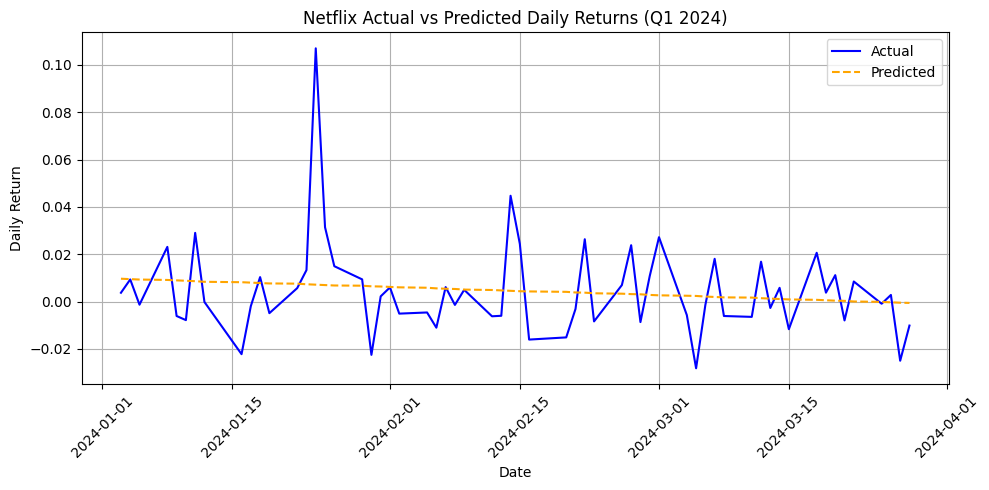

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Regression function with additional metrics
def perform_regression_daily_returns(data, company_name):
    """
    Performs linear regression of daily returns against DayIndex.
    Returns sklearn model, dataframe with predictions, and key metrics.
    """
    # Statsmodels regression for summary and ANOVA
    model_sm = smf.ols(formula='Q("Daily Return") ~ DayIndex', data=data).fit()

    print(f"\n===== {company_name} Regression Summary =====")
    print(model_sm.summary())

    # ANOVA table
    anova_table = sm.stats.anova_lm(model_sm, typ=2)
    print("\nANOVA Table:")
    print(anova_table)

    # Key metrics
    r_square = model_sm.rsquared
    adjusted_r_square = model_sm.rsquared_adj
    multiple_r = np.sqrt(r_square)
    standard_error = np.sqrt(model_sm.mse_resid)

    # Sklearn regression for predictions and RMSE
    X = data[['DayIndex']]
    y = data['Daily Return']
    model_sk = LinearRegression()
    model_sk.fit(X, y)
    y_pred = model_sk.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    # Add predictions to dataframe
    data['Predicted'] = y_pred

    metrics = {
        'Multiple R': multiple_r,
        'R Square': r_square,
        'Adjusted R Square': adjusted_r_square,
        'Standard Error': standard_error,
        'RMSE': rmse
    }

    return model_sk, data, metrics

# Perform regression
nflx_model, nflx_with_pred, nflx_metrics = perform_regression_daily_returns(nflx_2024, 'Netflix')

# Print summarized metrics
print("\nNetflix Regression Metrics (Daily Returns):")
for key, value in nflx_metrics.items():
    print(f"{key}: {value:.9f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(nflx_with_pred['Date'], nflx_with_pred['Daily Return'], label='Actual', color='blue')
plt.plot(nflx_with_pred['Date'], nflx_with_pred['Predicted'], label='Predicted', linestyle='--', color='orange')
plt.title('Netflix Actual vs Predicted Daily Returns (Q1 2024)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()